   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 8.6 MB/s eta 0:00:00
Mounted at /content/drive
Checking and downloading the Brugada-HUCA dataset...
Generating record list for: files/188981/188981
Generating record list for: files/251972/251972
Generating record list for: files/265715/265715
Generating record list for: files/267628/267628
Generating record list for: files/267630/267630
Generating record list for: files/286830/286830
Generating record list for: files/287355/287355
Generating record list for: files/292220/292220
Generating record list for: files/292666/292666
Generating record list for: files/304141/304141
Generating record list for: files/314397/314397
Generating record list for: files/316872/316872
Generating record list for: files/317547/317547
Generating record list for: files/319150/319150
Generating record list for: files/319221/319221
Generating record list for: files/325231/325231
Generating record list for: files/325966/325966
Generating record list fo

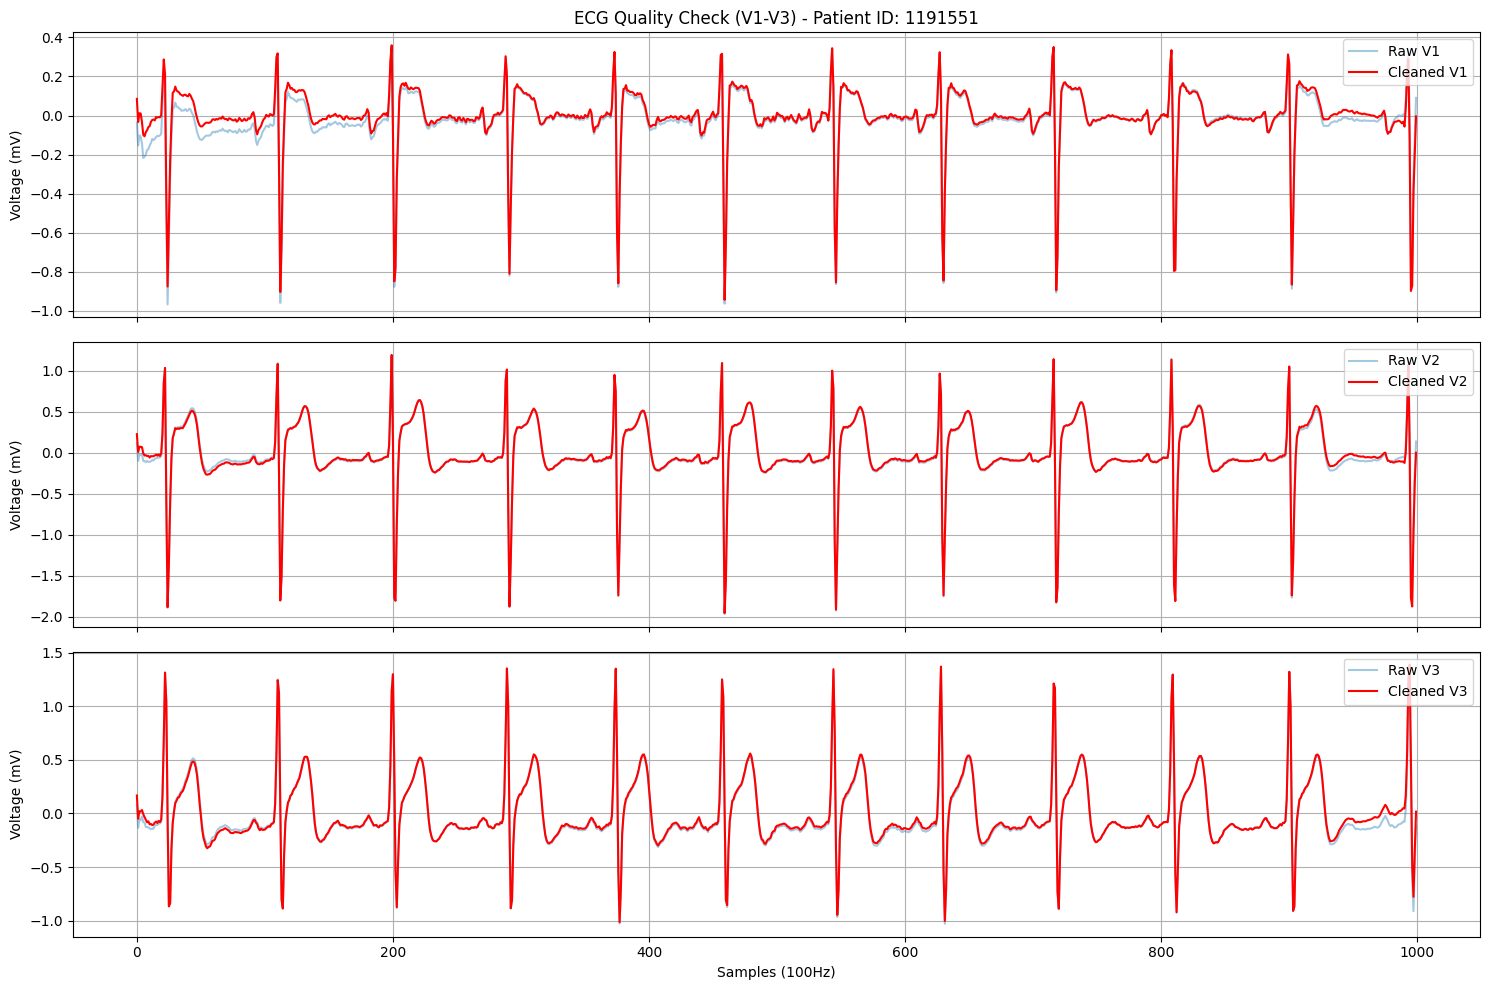

In [1]:
# ==========================================
# Stage 1 & 2: Data Downloading, Cleaning, and Feature Engineering
# (Ultimate Multi-Lead Version: V1, V2, V3)
# ==========================================

# 1. Install required libraries
!pip install wfdb matplotlib scipy pandas==2.2.2 -q

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# 3. Define project paths
base_path = '/content/drive/MyDrive/IDSC2026_Brugada_Project/'
raw_data_dir = os.path.join(base_path, 'raw_data')
os.makedirs(raw_data_dir, exist_ok=True)

print("Checking and downloading the Brugada-HUCA dataset...")
wfdb.dl_database('brugada-huca', dl_dir=raw_data_dir)
print("Data download completed or already exists!\n")

# A. Define bandpass filter (0.5Hz - 45Hz) to remove baseline wander and powerline noise
def clean_ecg_signal(signal, fs):
    nyq = 0.5 * fs
    low = 0.5 / nyq
    high = 45 / nyq
    b, a = butter(3, [low, high], btype='band')
    return filtfilt(b, a, signal)

# ==========================================
# Core Modification Area: V1-V3 Multi-Lead Feature Extraction
# ==========================================

print("Reading official metadata.csv to link true diagnostic labels...")
metadata_path = os.path.join(raw_data_dir, 'metadata.csv')

try:
    metadata_df = pd.read_csv(metadata_path)
    # Merge Class 2 into Class 1 (Ensure a 287 vs 76 binary split)
    metadata_df['brugada'] = metadata_df['brugada'].replace(2, 1)
    label_map = dict(zip(metadata_df['patient_id'].astype(str), metadata_df['brugada']))
    print(f"Successfully loaded {len(label_map)} official labels.")
except Exception as e:
    print(f"Error: Unable to read the label file. Error message: {e}")
    label_map = {}

files_dir = os.path.join(raw_data_dir, 'files')
all_ids = [d for d in os.listdir(files_dir) if os.path.isdir(os.path.join(files_dir, d))]
features_list = []

print(f"\nStarting to process {len(all_ids)} records, extracting features from V1, V2, and V3...")

for pid in all_ids:
    try:
        # 👑 Core Update: Read V1, V2, V3 leads (Indexes = 6, 7, 8)
        record_path = os.path.join(files_dir, pid, pid)
        record = wfdb.rdrecord(record_path, channels=[6, 7, 8])

        final_label = label_map.get(pid, 0)

        # Initialize dictionary for this patient
        patient_features = {
            'Patient_ID': pid,
            'Label': final_label
        }

        # Define leads and their corresponding column index in the extracted record
        lead_dict = {'V1': 0, 'V2': 1, 'V3': 2}

        # Loop through each of the 3 leads to extract features separately
        for lead_name, lead_idx in lead_dict.items():

            # 1. Signal cleaning for the specific lead
            raw_signal = record.p_signal[:, lead_idx]
            cleaned_signal = clean_ecg_signal(raw_signal, record.fs)

            # 2. Medical Feature Extraction (J-point and ST-segment slope)
            peaks, _ = find_peaks(cleaned_signal, distance=50, prominence=0.5)
            mean_j_amp = 0.0
            mean_st_slope = 0.0

            if len(peaks) > 0:
                j_point_offset = 5 # 5 points = 50ms (J-point location)
                j_amps, st_slopes = [], []
                for peak in peaks:
                    if peak + 15 < len(cleaned_signal):
                        j_idx = peak + j_point_offset
                        j_amp = cleaned_signal[j_idx]

                        st_end_amp = cleaned_signal[j_idx + 6]
                        slope = (st_end_amp - j_amp) / 6.0

                        j_amps.append(j_amp)
                        st_slopes.append(slope)

                if j_amps:
                    mean_j_amp = np.mean(j_amps)
                    mean_st_slope = np.mean(st_slopes)

            # 3. Add lead-specific features to the dictionary
            patient_features[f'{lead_name}_J_point_amp'] = mean_j_amp
            patient_features[f'{lead_name}_ST_slope'] = mean_st_slope
            patient_features[f'{lead_name}_95th_Percentile'] = np.percentile(cleaned_signal, 95)
            patient_features[f'{lead_name}_Std_Dev'] = np.std(cleaned_signal)
            patient_features[f'{lead_name}_Peak_to_Peak'] = np.ptp(cleaned_signal)
            patient_features[f'{lead_name}_Min_Voltage'] = np.min(cleaned_signal)

        # Append fully extracted patient data to the list
        features_list.append(patient_features)

    except Exception as e:
        continue # Skip corrupted files

# 3. Save as the final CSV table
final_df = pd.DataFrame(features_list)
csv_output = os.path.join(base_path, 'brugada_features_V1_to_V3.csv')
final_df.to_csv(csv_output, index=False)
print(f"\n✅ Task completed! Multi-lead feature table saved to: {csv_output}")
print(f"Total features extracted per patient: {len(final_df.columns) - 2} (excluding ID and Label)")

# ==========================================
# Visual Check (Plot V1, V2, V3 for the first patient)
# ==========================================
if all_ids:
    sample_id = all_ids[0]
    sample_rec = wfdb.rdrecord(os.path.join(files_dir, sample_id, sample_id), channels=[6, 7, 8])

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    lead_names = ['V1', 'V2', 'V3']

    for i in range(3):
        raw_sig = sample_rec.p_signal[:1000, i]
        cleaned_sig = clean_ecg_signal(raw_sig, sample_rec.fs)

        axes[i].plot(raw_sig, label=f'Raw {lead_names[i]}', alpha=0.4)
        axes[i].plot(cleaned_sig, label=f'Cleaned {lead_names[i]}', color='red')
        axes[i].set_ylabel("Voltage (mV)")
        axes[i].legend(loc="upper right")
        axes[i].grid(True)

    axes[0].set_title(f"ECG Quality Check (V1-V3) - Patient ID: {sample_id}")
    axes[-1].set_xlabel("Samples (100Hz)")

    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'ECG_Plot_V1_V3_{sample_id}.png'))
    plt.show()

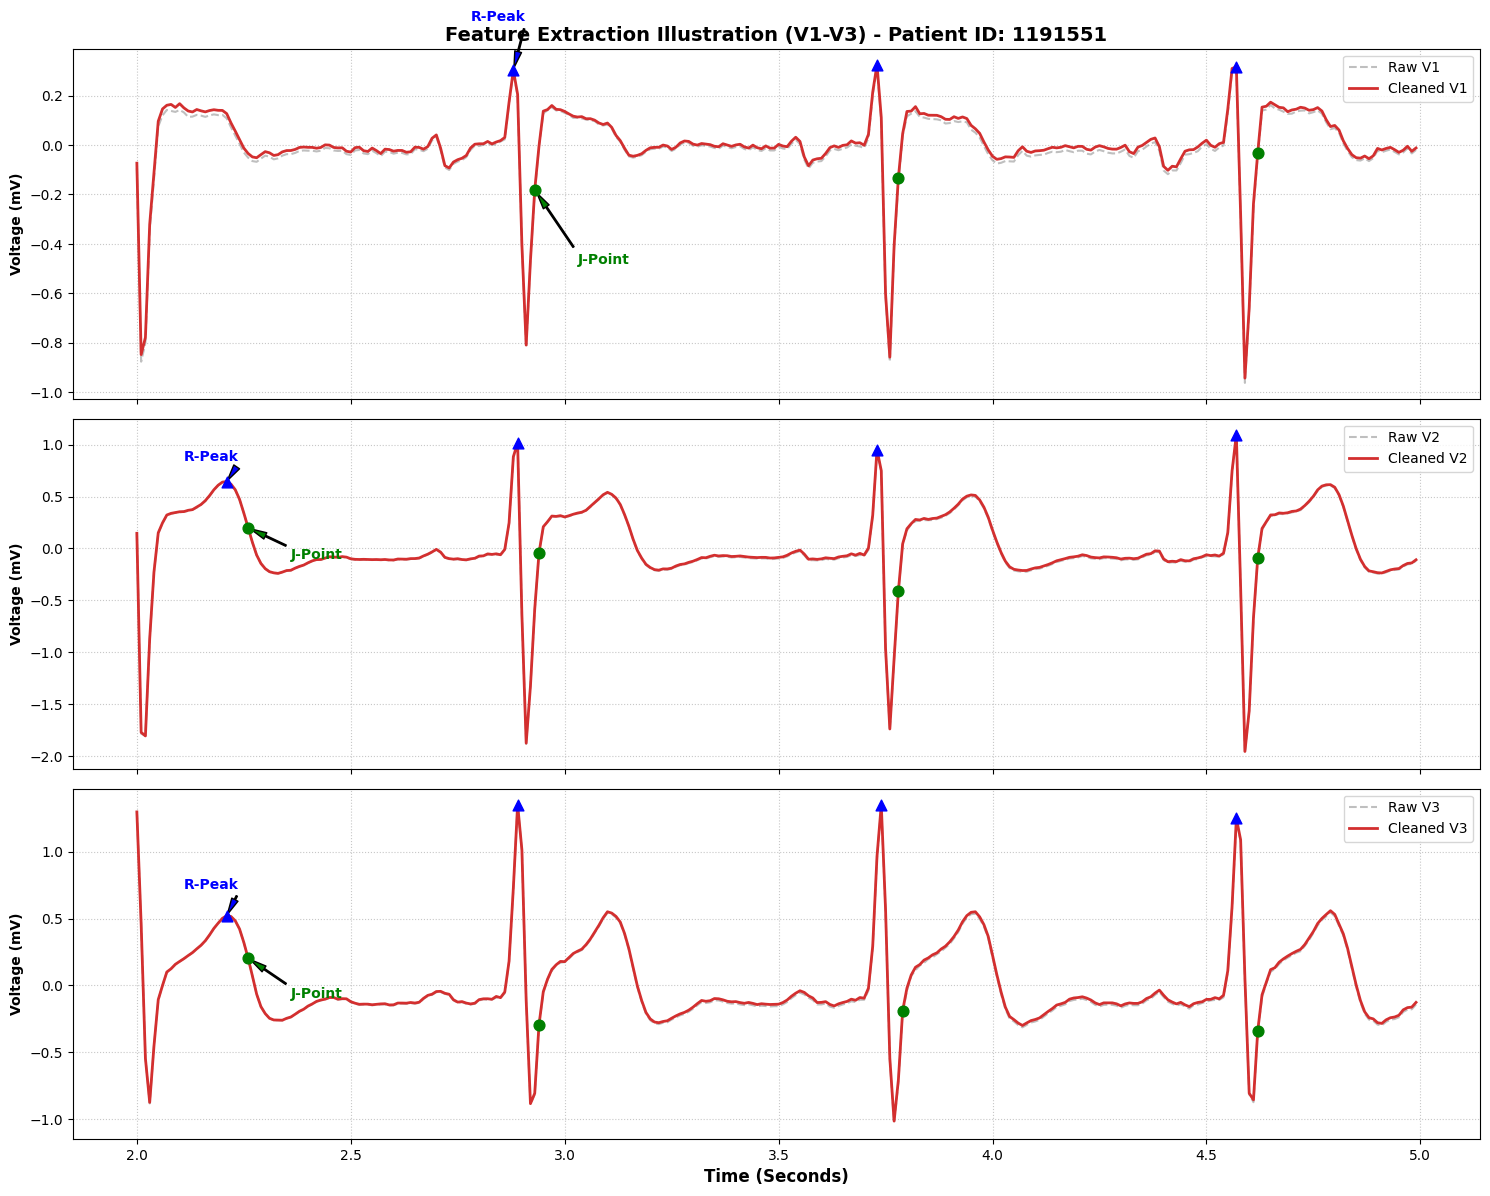

In [4]:
# ==========================================
# V1-V3 3s Macro-Close-up
# ==========================================
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import numpy as np
import os
import wfdb

if all_ids:
    sample_id = all_ids[0]
    # Load record with specific chest leads (V1, V2, V3)
    sample_rec = wfdb.rdrecord(os.path.join(files_dir, sample_id, sample_id), channels=[6, 7, 8])

    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    lead_names = ['V1', 'V2', 'V3']

    # Define window for cropping (300 samples = approx 3 seconds at 100Hz)
    start_idx = 200
    end_idx = start_idx + 300
    j_point_offset = 5 # 50ms after R-peak

    for i in range(3):
        # 1. Filtering and Segmentation
        full_raw_sig = sample_rec.p_signal[:, i]
        full_cleaned_sig = clean_ecg_signal(full_raw_sig, sample_rec.fs)

        raw_segment = full_raw_sig[start_idx:end_idx]
        cleaned_segment = full_cleaned_sig[start_idx:end_idx]
        time_axis = np.arange(start_idx, end_idx) / sample_rec.fs

        # 2. Peak Detection (R-wave) within the 3-second window
        peaks, _ = find_peaks(cleaned_segment, distance=50, prominence=0.5)

        # 3. Plot Base Waveforms
        axes[i].plot(time_axis, raw_segment, label=f'Raw {lead_names[i]}', alpha=0.5, color='gray', linestyle='--')
        axes[i].plot(time_axis, cleaned_segment, label=f'Cleaned {lead_names[i]}', color='#D32F2F', linewidth=2)

        # 4. Dynamic Annotation of R-peaks and J-points
        for peak in peaks:
            r_time = time_axis[peak]
            r_amp = cleaned_segment[peak]

           # Mark R-Peak
            axes[i].scatter(r_time, r_amp, color='blue', s=60, zorder=5, marker='^')

            # Mark J-Point
            if peak + j_point_offset < len(cleaned_segment):
                j_idx = peak + j_point_offset
                j_time = time_axis[j_idx]
                j_amp = cleaned_segment[j_idx]

                axes[i].scatter(j_time, j_amp, color='green', s=60, zorder=5, marker='o')

                if peak == peaks[0]:
                    axes[i].annotate('R-Peak', xy=(r_time, r_amp), xytext=(r_time - 0.1, r_amp + 0.2),
                                     arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=5),
                                     fontsize=10, color='blue', fontweight='bold')
                    axes[i].annotate('J-Point', xy=(j_time, j_amp), xytext=(j_time + 0.1, j_amp - 0.3),
                                     arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
                                     fontsize=10, color='green', fontweight='bold')

        axes[i].set_ylabel("Voltage (mV)", fontweight='bold')
        axes[i].legend(loc="upper right")
        axes[i].grid(True, linestyle=':', alpha=0.7)

    axes[0].set_title(f"Feature Extraction Illustration (V1-V3) - Patient ID: {sample_id}", fontsize=14, fontweight='bold')
    axes[-1].set_xlabel("Time (Seconds)", fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(base_path, f'ECG_Plot_Ultimate_V1_V3_{sample_id}.png'), dpi=300)
    plt.show()